In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



c:\Users\Windows11\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATA LOAD

In [3]:
df_raw = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv") # original dataset
df_eda = df_raw.copy() #for exploratory data analysis
df_model  = df_raw.copy() # for modeling 

In [4]:
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df_raw .shape
df_raw.info()
df_raw.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df_raw.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

EDA (preprocessing)

In [7]:
df_eda.drop("customerID", axis=1, inplace=True)  
df_eda["SeniorCitizen"] = df_eda["SeniorCitizen"].map({0: "No", 1: "Yes"})  

In [8]:
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce") 
df_eda["TotalCharges"] = df_eda["TotalCharges"].fillna(df_eda["TotalCharges"].median()) 

In [9]:
numeric_cols = df_eda.select_dtypes(include=["int64", "float64"]).columns 
categorical_cols = df_eda.select_dtypes(include=["object", "string", "category", "bool"]).columns 

In [10]:
print("df_eda shape:", df_eda.shape)
df_eda.info()
df_eda.isnull().sum()

df_eda shape: (7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-n

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

EDA

In [11]:
print("Numeric columns:")
print(numeric_cols)
print("Categorical columns:")
print(categorical_cols)

Numeric columns:
Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Categorical columns:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


In [12]:
print("Churn counts:")
print(df_eda["Churn"].value_counts())
print("Churn ratio:")
print(df_eda["Churn"].value_counts(normalize=True)) #imbalance

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn ratio:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


Approximately 26.6% of customers have churned, indicating a moderate class imbalance in the dataset.

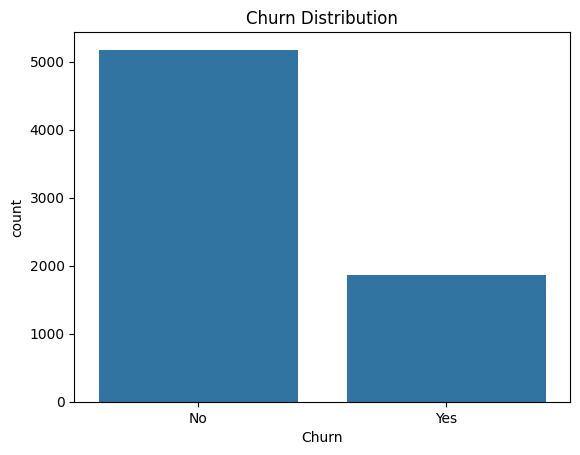

In [13]:
sns.countplot(x="Churn", data=df_eda)
plt.title("Churn Distribution")
plt.show()                                  

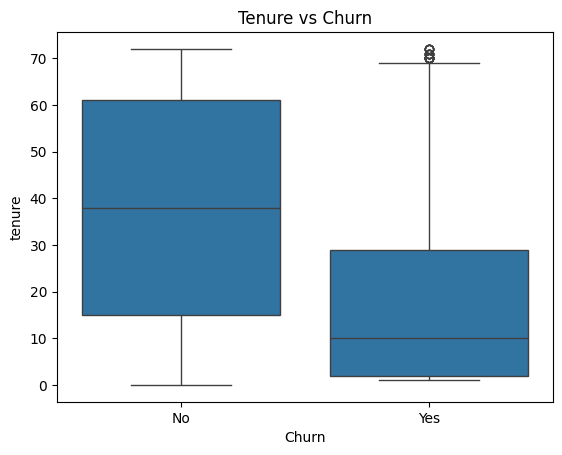

In [14]:
sns.boxplot(x="Churn", y="tenure", data=df_eda)
plt.title("Tenure vs Churn")
plt.show()

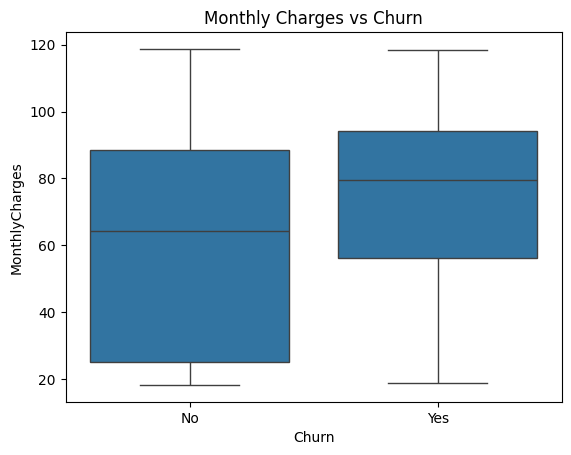

In [15]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df_eda)
plt.title("Monthly Charges vs Churn")
plt.show()

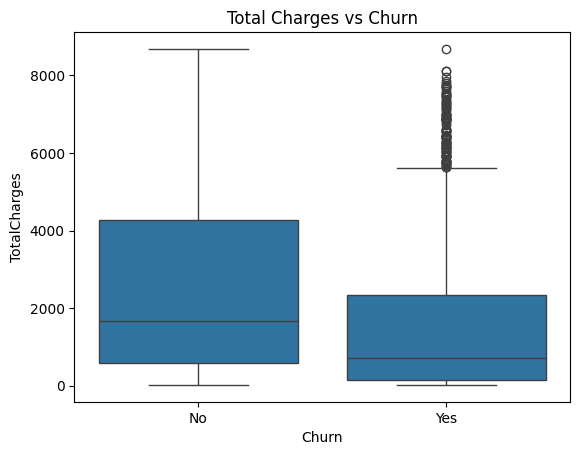

In [16]:
sns.boxplot(x="Churn", y="TotalCharges", data=df_eda)
plt.title("Total Charges vs Churn")
plt.show()

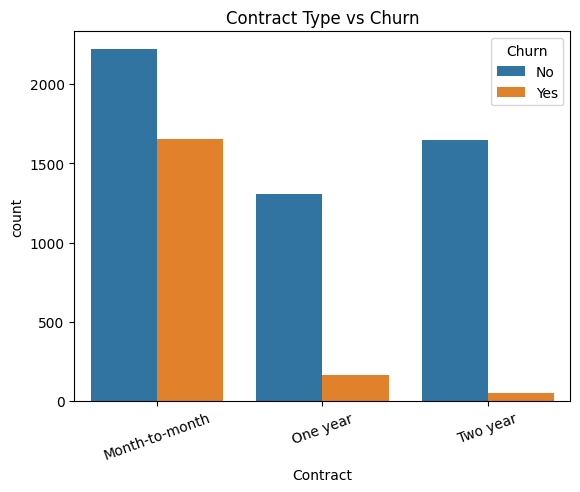

In [17]:
sns.countplot(x="Contract", hue="Churn", data=df_eda)
plt.xticks(rotation=20)
plt.title("Contract Type vs Churn")
plt.show()

In [18]:
df_eda.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

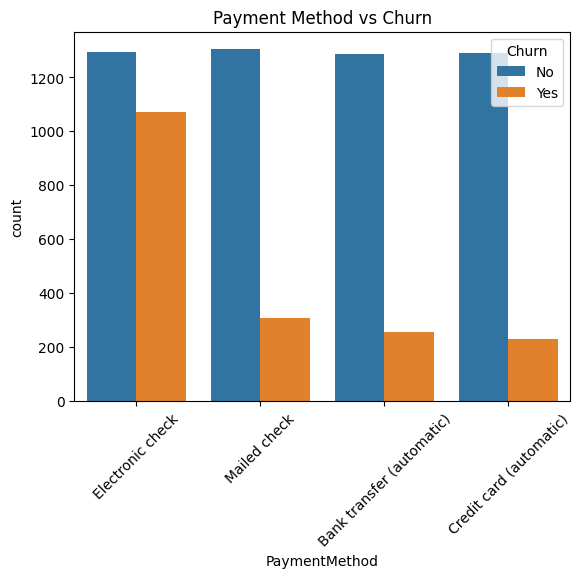

In [19]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df_eda)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

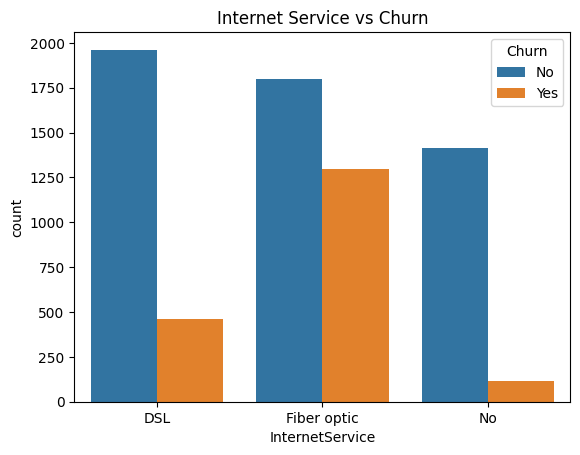

In [20]:
sns.countplot(x="InternetService", hue="Churn", data=df_eda)
plt.title("Internet Service vs Churn")
plt.show()

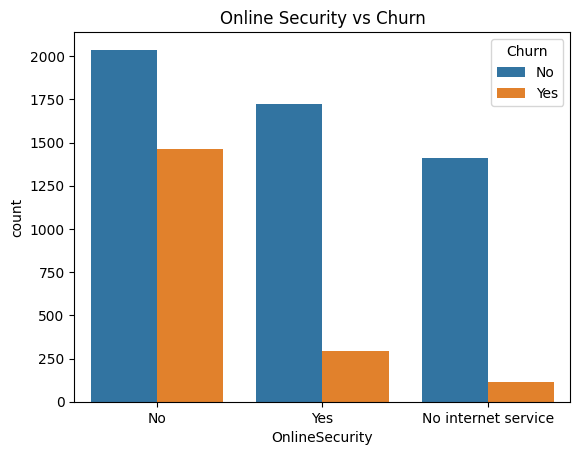

In [21]:
sns.countplot(x="OnlineSecurity", hue="Churn", data=df_eda)
plt.title("Online Security vs Churn")
plt.show()

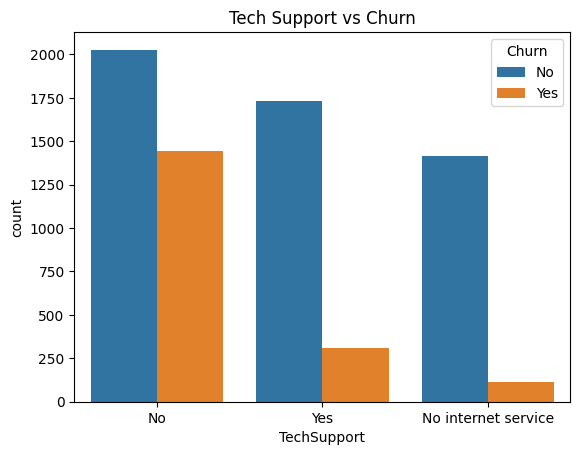

In [22]:
sns.countplot(x="TechSupport", hue="Churn", data=df_eda)
plt.title("Tech Support vs Churn")
plt.show()

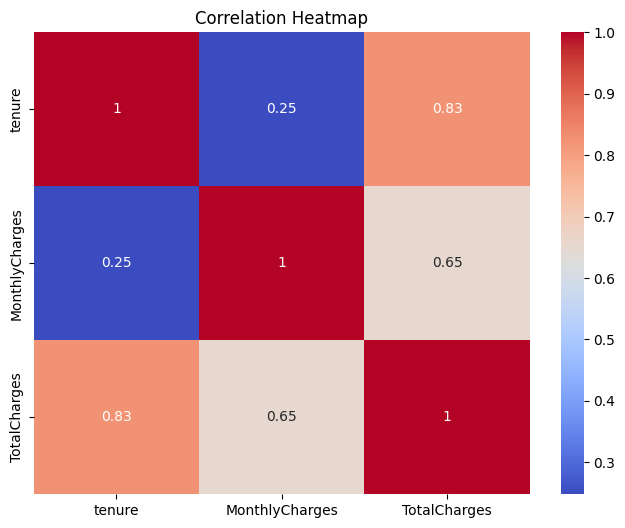

In [23]:
numeric_df_eda = df_eda.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df_eda.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

Key Insights

Customers with shorter tenure are more likely to churn.

Higher monthly charges are associated with slightly higher churn rates.

Month-to-month contracts exhibit significantly higher churn compared to long-term contracts.

Customers with fiber optic internet service tend to churn more frequently.

Electronic check payment method shows higher churn rates.

Section 1. Baseline Model

1) Modeling preprocessing (without FE)

In [24]:
df_model.drop("customerID", axis=1, inplace=True) #customerID is an identifier, so drop it.

In [25]:
df_model["SeniorCitizen"] = df_model["SeniorCitizen"].map({0: "No", 1: "Yes"}) 

In [26]:
df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors="coerce") 

In [27]:
df_model["TotalCharges"] = df_model["TotalCharges"].fillna(df_model["TotalCharges"].median()) 

In [28]:
df_model["Churn"] = df_model["Churn"].map({"No": 0, "Yes": 1}) 

In [29]:
df_model = pd.get_dummies(df_model, drop_first=True) 

In [30]:
print(df_model.shape)
df_model.info()

(7043, 31)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   int64  
 1   MonthlyCharges                         7043 non-null   float64
 2   TotalCharges                           7043 non-null   float64
 3   Churn                                  7043 non-null   int64  
 4   gender_Male                            7043 non-null   bool   
 5   SeniorCitizen_Yes                      7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

2) Modeling - logistic regression (baseline)

In [31]:
X_base = df_model.drop("Churn", axis=1) # exclude the target variable Churn to create the feature set X_base
y_base = df_model["Churn"] # set the target variable Churn as y_base
print("X shape:", X_base.shape)
print("y shape:", y_base.shape)

X shape: (7043, 30)
y shape: (7043,)


In [32]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_base,
    test_size=0.2,
    random_state=42,
    stratify=y_base
) # stratify=y_base to maintain class distribution in train and test sets

In [33]:
scaler_base = StandardScaler() 

Xb_train = scaler_base.fit_transform(Xb_train) 
Xb_test = scaler_base.transform(Xb_test) 

In [34]:
log_base = LogisticRegression(max_iter=2000)

log_base.fit(Xb_train, yb_train)

yb_pred = log_base.predict(Xb_test)
yb_prob = log_base.predict_proba(Xb_test)[:,1]

In [35]:
base_accuracy = accuracy_score(yb_test, yb_pred)
base_precision = precision_score(yb_test, yb_pred)
base_recall = recall_score(yb_test, yb_pred)
base_f1 = f1_score(yb_test, yb_pred)
base_auc = roc_auc_score(yb_test, yb_prob)

print("Logistic Performance(Baseline)")
print("Accuracy:", base_accuracy)
print("Precision:", base_precision)
print("Recall:", base_recall)
print("F1:", base_f1)
print("ROC-AUC:", base_auc)

Logistic Performance(Baseline)
Accuracy: 0.8069552874378992
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1: 0.6091954022988506
ROC-AUC: 0.8415846443979436


The purpose of this step was to establish a baseline — that is, to assess how well the model performs without any feature engineering, serving as a reference point for comparison.

Section 2. Feature Engineering

- The following 8 features were engineered based on patterns identified in the EDA phase. Each feature is designed to capture a specific churn risk signal observed in the data.

1. Basic preprocessing

In [36]:
df_fe = df_raw.copy()

In [37]:
df_fe.drop("customerID", axis=1, inplace=True)

In [38]:
# SeniorCitizen categorical
df_fe["SeniorCitizen"] = df_fe["SeniorCitizen"].map({0: "No", 1: "Yes"})

# TotalCharges numeric
df_fe["TotalCharges"] = pd.to_numeric(df_fe["TotalCharges"], errors="coerce")
df_fe["TotalCharges"] = df_fe["TotalCharges"].fillna(df_fe["TotalCharges"].median())

# target
df_fe["Churn"] = df_fe["Churn"].map({"No":0,"Yes":1})

2. Feature engineering 로써 8개의 변수 추가 

(a) tenure_group

In [39]:
df_fe["tenure_group"] = pd.cut(df_fe["tenure"],bins=[0,12,24,48,72],labels=["0-12","12-24","24-48","48+"],include_lowest=True)

# tenure serves as a proxy for customer loyalty; grouping it into ranges helps capture churn patterns more effectively
# new customers tend to have higher churn rates, while long-term customers tend to have lower ones


(b) avg_monthly_spend

In [40]:
df_fe["avg_monthly_spend"] = df_fe["TotalCharges"] / (df_fe["tenure"] + 1)  

# MonthlyCharges alone only reflects the current charge
# TotalCharges alone grows larger the longer a customer stays, regardless of spending behavior
# combining the two provides a better view of actual spending patterns

(c) contract_risk

In [41]:
df_fe["contract_risk"] = np.where(df_fe["Contract"] == "Month-to-month",1,0)   

# customers on month-to-month contracts tend to have higher churn rates

(d) services

In [42]:
services = ["PhoneService","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

df_fe["service_count"] = (df_fe[services] == "Yes").sum(axis=1) #customers subscribed to more services tend to have lower churn rates


(e) long_term_customer

In [43]:
df_fe["long_term_customer"] = np.where(df_fe["tenure"] > 24, 1, 0) #indicates whether the customer is a long-term subscriber


(f) high_monthly_charge

In [44]:
df_fe["high_monthly_charge"] = np.where(df_fe["MonthlyCharges"] > df_fe["MonthlyCharges"].median(), 1,0) #customers with higher monthly charges tend to have higher churn rates

(g) no_security

In [45]:
df_fe["no_security"] = np.where(df_fe["OnlineSecurity"] == "No",1,0)# customers without security services tend to have higher churn rates

(h) auto_payment

In [46]:
df_fe["auto_payment"] = np.where(df_fe["PaymentMethod"].str.contains("automatic"),1,0)# customers with automatic payment tend to have lower churn rates

3) Encoding

In [47]:
df_fe = pd.get_dummies(df_fe, drop_first=True)

Section 3: Models

1. LOGISTIC REGRESSION

1) Modeling the final logistic regression (feature engineered)

In [48]:
X = df_fe.drop("Churn", axis=1)
y = df_fe["Churn"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, 
    stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 40) (1409, 40)


In [50]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

2) Logistic regression(feature engineered)

In [51]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

In [52]:
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

* "Logistic Performance (feature engineered) vs Logistic Performance (baseline)"

In [53]:
print("Logistic Performance (feature engineered) vs Logistic Performance (baseline)")
print("Accuracy:", log_accuracy, "vs", base_accuracy)
print("Precision:", log_precision, "vs", base_precision)
print("Recall:", log_recall, "vs", base_recall)
print("F1:", log_f1, "vs", base_f1)
print("ROC-AUC:", log_auc, "vs", base_auc)


Logistic Performance (feature engineered) vs Logistic Performance (baseline)
Accuracy: 0.8048261178140526 vs 0.8069552874378992
Precision: 0.6677966101694915 vs 0.6583850931677019
Recall: 0.5267379679144385 vs 0.5668449197860963
F1: 0.5889387144992526 vs 0.6091954022988506
ROC-AUC: 0.8460642227905654 vs 0.8415846443979436


3) logistics(balanced)

In this project, the Logistic Regression model with class imbalance handling will be used for comparison with other models, as it provides a fair evaluation by appropriately addressing the imbalance in the dataset.

In [54]:
log_model_bal = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    solver='liblinear',
    random_state=42
)

log_model_bal.fit(X_train, y_train)

y_pred_log_bal = log_model_bal.predict(X_test)
y_prob_log_bal = log_model_bal.predict_proba(X_test)[:, 1]

In [55]:
log_bal_accuracy = accuracy_score(y_test, y_pred_log_bal)
log_bal_precision = precision_score(y_test, y_pred_log_bal)
log_bal_recall = recall_score(y_test, y_pred_log_bal)
log_bal_f1 = f1_score(y_test, y_pred_log_bal)
log_bal_auc = roc_auc_score(y_test, y_prob_log_bal)

In [56]:
print("Logistic Performance(Balanced) vs Logistic Performance(Feature Engineered)")
print("Accuracy:", log_bal_accuracy, "vs", log_accuracy)
print("Precision:", log_bal_precision, "vs", log_precision)
print("Recall:", log_bal_recall, "vs", log_recall)
print("F1:", log_bal_f1, "vs", log_f1)
print("ROC-AUC:", log_bal_auc, "vs", log_auc)

Logistic Performance(Balanced) vs Logistic Performance(Feature Engineered)
Accuracy: 0.7388218594748048 vs 0.8048261178140526
Precision: 0.5051369863013698 vs 0.6677966101694915
Recall: 0.7887700534759359 vs 0.5267379679144385
F1: 0.615866388308977 vs 0.5889387144992526
ROC-AUC: 0.8457542173654706 vs 0.8460642227905654


2. DECISION TREE

In [57]:
tree_model = DecisionTreeClassifier(max_depth=5,class_weight='balanced',random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:,1]

In [58]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
tree_auc = roc_auc_score(y_test, y_prob_tree)

In [59]:
results = pd.DataFrame({
    "Model":["Logistic Regression(balanced)","Decision Tree"],
    "Accuracy":[log_bal_accuracy, tree_accuracy],
    "Precision":[log_bal_precision, tree_precision],
    "Recall":[log_bal_recall, tree_recall],
    "F1":[log_bal_f1, tree_f1],
    "AUC":[log_bal_auc, tree_auc]
})

results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression(balanced),0.738822,0.505137,0.788770,0.615866,0.845754
1,Decision Tree,0.752307,0.522523,0.775401,0.624327,0.832870


3. RANDOM FOREST

In [60]:
rf_model = RandomForestClassifier(n_estimators=200,class_weight='balanced',max_depth=8,min_samples_split=10,min_samples_leaf=4,random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [61]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

In [62]:
results = pd.DataFrame({
    "Model":["Logistic Regression(balanced)","Decision Tree","Random Forest"],
    "Accuracy":[log_bal_accuracy, tree_accuracy, rf_accuracy],
    "Precision":[log_bal_precision, tree_precision, rf_precision],
    "Recall":[log_bal_recall, tree_recall, rf_recall],
    "F1":[log_bal_f1, tree_f1, rf_f1],
    "AUC":[log_bal_auc, tree_auc, rf_auc]
})

results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression(balanced),0.738822,0.505137,0.788770,0.615866,0.845754
1,Decision Tree,0.752307,0.522523,0.775401,0.624327,0.832870
2,Random Forest,0.762243,0.535912,0.778075,0.634678,0.844111


4. XGBOOST

In [63]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

xgb_model = XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,random_state=42,eval_metric="logloss",scale_pos_weight=scale_pos_weight)

xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost Precision:", xgb_precision)
print("XGBoost Recall:", xgb_recall)
print("XGBoost F1:", xgb_f1)
print("XGBoost AUC:", xgb_auc)


XGBoost Accuracy: 0.7551454932576295
XGBoost Precision: 0.5261261261261261
XGBoost Recall: 0.7807486631016043
XGBoost F1: 0.628632938643703
XGBoost AUC: 0.8429861272572269


In [64]:
results = pd.DataFrame({
    "Model":["Logistic Regression(balanced)","Decision Tree","Random Forest","XGBoost"],
    "Accuracy":[log_bal_accuracy, tree_accuracy, rf_accuracy, xgb_accuracy],
    "Precision":[log_bal_precision, tree_precision, rf_precision, xgb_precision],
    "Recall":[log_bal_recall, tree_recall, rf_recall, xgb_recall],
    "F1":[log_bal_f1, tree_f1, rf_f1, xgb_f1],
    "AUC":[log_bal_auc, tree_auc, rf_auc, xgb_auc]
})

results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression(balanced),0.738822,0.505137,0.788770,0.615866,0.845754
1,Decision Tree,0.752307,0.522523,0.775401,0.624327,0.832870
2,Random Forest,0.762243,0.535912,0.778075,0.634678,0.844111
3,XGBoost,0.755145,0.526126,0.780749,0.628633,0.842986


5. NEURAL NETWORK(FNN)

In [65]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

nn_model = Sequential()

nn_model.add(Input(shape=(X_train.shape[1],)))
nn_model.add(Dense(64, activation="relu"))
nn_model.add(Dropout(0.3))

nn_model.add(Dense(32, activation="relu"))
nn_model.add(Dropout(0.2))

nn_model.add(Dense(1, activation="sigmoid"))

nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)


{np.int64(0): np.float64(0.6805991785455424), np.int64(1): np.float64(1.8842809364548494)}


In [67]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [68]:
history = nn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6718 - loss: 0.5789 - val_accuracy: 0.6903 - val_loss: 0.5681
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7393 - loss: 0.5051 - val_accuracy: 0.7161 - val_loss: 0.5355
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7457 - loss: 0.4983 - val_accuracy: 0.7152 - val_loss: 0.5268
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7517 - loss: 0.4923 - val_accuracy: 0.7169 - val_loss: 0.5296
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7535 - loss: 0.4865 - val_accuracy: 0.7196 - val_loss: 0.5197
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7570 - loss: 0.4813 - val_accuracy: 0.7187 - val_loss: 0.5244
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7613 - loss: 0.4802 - val_accuracy: 0.7187 - val_loss: 0.5212
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7564 - loss: 0.4851 - val_accu

In [69]:
y_prob_nn = nn_model.predict(X_test).flatten()

threshold = 0.5
y_pred_nn = (y_prob_nn >= threshold).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [70]:
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn)
nn_recall = recall_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)
nn_auc = roc_auc_score(y_test, y_prob_nn)

print("Neural Network:")
print("Accuracy:", nn_accuracy)
print("Precision:", nn_precision)
print("Recall:", nn_recall)
print("F1:", nn_f1)
print("AUC:", nn_auc)

Neural Network:
Accuracy: 0.7452093683463449
Precision: 0.5134649910233393
Recall: 0.7647058823529411
F1: 0.6143931256713212
AUC: 0.8405900436590974


Section 4. Model Evaluation

1. ROC Curve comparison

In [71]:
fpr_log_bal, tpr_log_bal, _ = roc_curve(y_test, y_prob_log_bal)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)

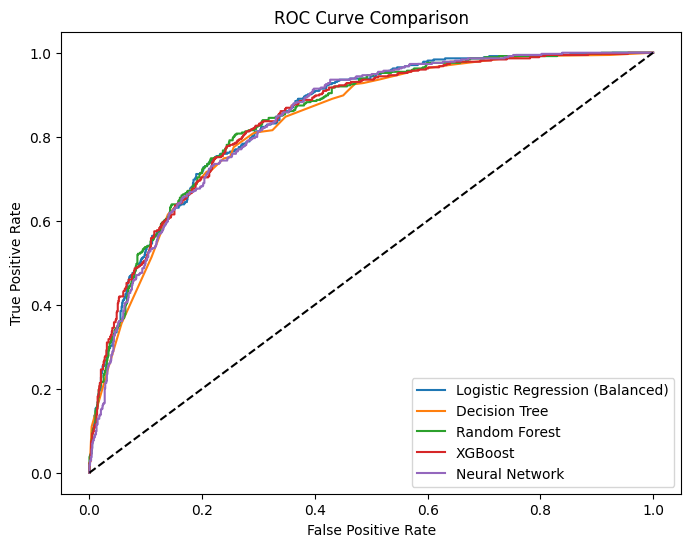

In [72]:
plt.figure(figsize=(8,6))

plt.plot(fpr_log_bal, tpr_log_bal, label="Logistic Regression (Balanced)")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot(fpr_nn, tpr_nn, label="Neural Network")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [73]:
from sklearn.metrics import auc
print("Logistic (balanced) AUC:", auc(fpr_log_bal, tpr_log_bal))
print("Decision Tree AUC:", auc(fpr_tree, tpr_tree))
print("Random Forest AUC:", auc(fpr_rf, tpr_rf))
print("XGBoost AUC:", auc(fpr_xgb, tpr_xgb))
print("Neural Network AUC:", auc(fpr_nn, tpr_nn))

Logistic (balanced) AUC: 0.8457542173654706
Decision Tree AUC: 0.8328696168849622
Random Forest AUC: 0.8441111886124673
XGBoost AUC: 0.8429861272572269
Neural Network AUC: 0.8405900436590974


2. Recall comparison

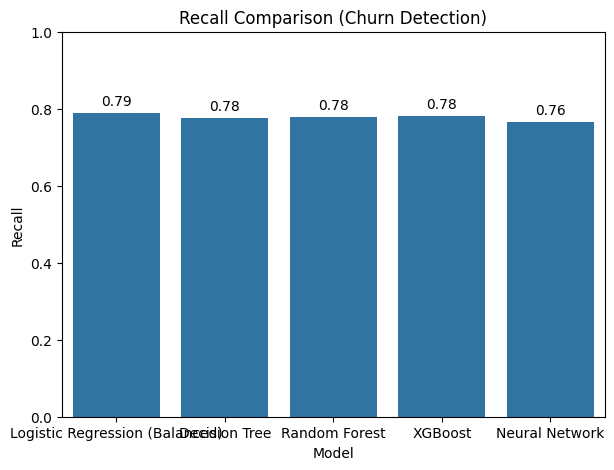

In [74]:
recall_df = pd.DataFrame({
    "Model": [
        "Logistic Regression (Balanced)",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "Recall": [
        log_bal_recall,
        tree_recall,
        rf_recall,
        xgb_recall,
        nn_recall
    ]
})

plt.figure(figsize=(7,5))

sns.barplot(x="Model", y="Recall", data=recall_df)

plt.title("Recall Comparison (Churn Detection)")

plt.ylim(0,1)

for i, v in enumerate(recall_df["Recall"]):
    
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.show()

3. Precision VS recall comparison

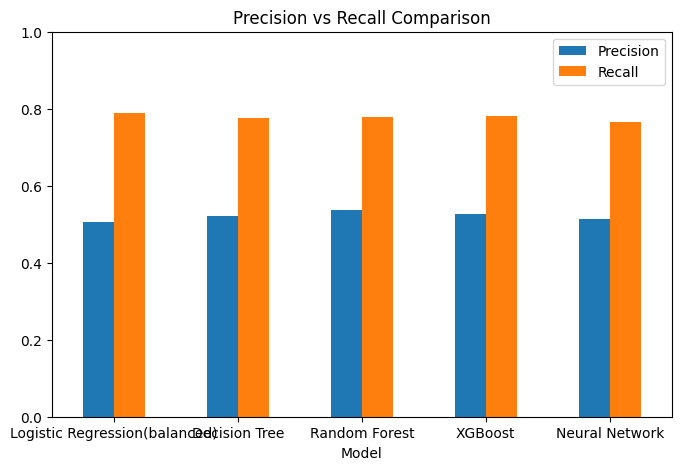

In [75]:
pr_df = pd.DataFrame({

    "Model": ["Logistic Regression(balanced)","Decision Tree","Random Forest","XGBoost","Neural Network"],

    "Precision": [log_bal_precision,tree_precision,rf_precision,xgb_precision,nn_precision],

    "Recall": [log_bal_recall,tree_recall,rf_recall,xgb_recall,nn_recall]
})

pr_df.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.title("Precision vs Recall Comparison")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.show()

In [76]:
print(pr_df)

                           Model  Precision    Recall
0  Logistic Regression(balanced)   0.505137  0.788770
1                  Decision Tree   0.522523  0.775401
2                  Random Forest   0.535912  0.778075
3                        XGBoost   0.526126  0.780749
4                 Neural Network   0.513465  0.764706


In [77]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

threshold = 0.5

model_probs = {
    "Logistic Regression (balanced)": y_prob_log_bal,
    "Decision Tree": y_prob_tree,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb,
    "Neural Network": y_prob_nn
}

results = []

for model_name, y_prob in model_probs.items():
    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Model": model_name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred)
    })

result_df = pd.DataFrame(results)
result_df

,Model,Precision,Recall,F1,Accuracy
0,Logistic Regression (balanced),0.505137,0.788770,0.615866,0.738822
1,Decision Tree,0.522523,0.775401,0.624327,0.752307
2,Random Forest,0.535912,0.778075,0.634678,0.762243
3,XGBoost,0.526126,0.780749,0.628633,0.755145
4,Neural Network,0.513465,0.764706,0.614393,0.745209


- At the default threshold of 0.5, Random Forest achieves the highest F1 score, indicating the best balance between precision and recall among the models.

- However, the goal of this project is not to maximize F1, but to maximize recall for churn detection. 

- So, XGBoost also needs to be reviewed again because it maintains a reasonable balance while still achieving a relatively high recall value.

Section 5. Threshold Optimization (RF vs XGB)

To evaluate the impact of threshold adjustment, both Random Forest and XGBoost were analyzed across multiple threshold values.

1. threshold tuning

In [78]:
thresholds = [0.2,0.25,0.3, 0.35, 0.4, 0.45, 0.5]

compare_results = []

models = {
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb
}

for model_name, y_prob in models.items():
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        compare_results.append({
            "Model": model_name,
            "Threshold": t,
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred)
        })

compare_df = pd.DataFrame(compare_results)
compare_df

,Model,Threshold,Precision,Recall,F1
0,Random Forest,0.20,0.389738,0.954545,0.553488
1,Random Forest,0.25,0.418689,0.922460,0.575960
2,Random Forest,0.30,0.438735,0.890374,0.587820
3,Random Forest,0.35,0.462411,0.871658,0.604263
4,Random Forest,0.40,0.489130,0.842246,0.618861
5,Random Forest,0.45,0.512648,0.812834,0.628749
6,Random Forest,0.50,0.535912,0.778075,0.634678
7,XGBoost,0.20,0.393973,0.943850,0.555906
8,XGBoost,0.25,0.420606,0.927807,0.578816
9,XGBoost,0.30,0.441558,0.909091,0.594406


In [79]:
# Precision maximizing whle maintaining Recall >= 90% for XGBoost

best_threshold = None
best_precision = 0

for t in np.arange(0.1, 0.9, 0.01):
    y_pred = (y_prob_xgb >= t).astype(int)
    r = recall_score(y_test, y_pred)
    p = precision_score(y_test, y_pred)
    
    if r >= 0.90 and p > best_precision:
        best_precision = p
        best_threshold = t

print("Best threshold:", best_threshold)
print("Precision:", best_precision)

Best threshold: 0.29999999999999993
Precision: 0.44155844155844154


In [80]:
best_threshold = 0.30  

y_pred_best = (y_prob_xgb >= best_threshold).astype(int)

print("Best Threshold:", best_threshold)
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best))
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Best Threshold: 0.3
Precision: 0.44155844155844154
Recall: 0.9090909090909091
F1: 0.5944055944055944
Accuracy: 0.6706884315117104
ROC-AUC: 0.8429861272572269


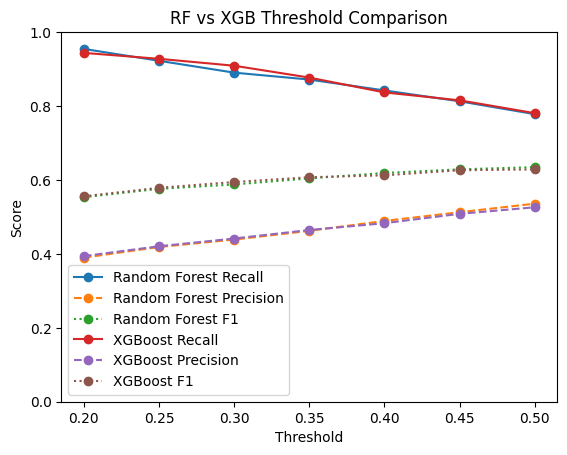

In [81]:
import matplotlib.pyplot as plt

for model in ["Random Forest", "XGBoost"]:
    df_temp = compare_df[compare_df["Model"] == model]

    plt.plot(df_temp["Threshold"], df_temp["Recall"], marker="o", label=f"{model} Recall")
    plt.plot(df_temp["Threshold"], df_temp["Precision"], marker="o", linestyle="--", label=f"{model} Precision")
    plt.plot(df_temp["Threshold"], df_temp["F1"], marker="o", linestyle=":", label=f"{model} F1")


plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("RF vs XGB Threshold Comparison")
plt.legend()
plt.ylim(0,1)
plt.show()

- XGBoost achieves higher recall while incurring only a small loss in precision.
- Therefore, XGBoost was selected..

In [82]:
best_threshold = 0.3

y_pred_xgb_final = (y_prob_xgb >= best_threshold).astype(int)

xgb_final_accuracy = accuracy_score(y_test, y_pred_xgb_final)
xgb_final_precision = precision_score(y_test, y_pred_xgb_final)
xgb_final_recall = recall_score(y_test, y_pred_xgb_final)
xgb_final_f1 = f1_score(y_test, y_pred_xgb_final)
xgb_final_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost(0.3):")
print("Accuracy:", xgb_final_accuracy)
print("Precision:", xgb_final_precision)
print("Recall:", xgb_final_recall)
print("F1:", xgb_final_f1)
print("AUC:", xgb_final_auc)

XGBoost(0.3):
Accuracy: 0.6706884315117104
Precision: 0.44155844155844154
Recall: 0.9090909090909091
F1: 0.5944055944055944
AUC: 0.8429861272572269


***best_model = "XGBoost"
***best_threshold = 0.3

Section 6. Model Optimization Experiments(optional)

In this section, additional optimization experiments were conducted to further explore potential improvements in model performance. These experiments focus on refining the model through hyperparameter tuning and validating the robustness of the model’s behavior beyond the main analysis.

1. Quick sanity check

In [83]:
thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:

    y_pred = (y_prob_xgb > t).astype(int)

    print("Threshold:", t)
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("-----------------------------------------------------")

Threshold: 0.3
Recall: 0.9090909090909091
Precision: 0.44155844155844154
-----------------------------------------------------
Threshold: 0.4
Recall: 0.8368983957219251
Precision: 0.48302469135802467
-----------------------------------------------------
Threshold: 0.5
Recall: 0.7807486631016043
Precision: 0.5261261261261261
-----------------------------------------------------
Threshold: 0.6
Recall: 0.6978609625668449
Precision: 0.5600858369098712
-----------------------------------------------------


2. GridSearch

In [84]:
param_grid = {"max_depth": [3, 5, 7],"learning_rate": [0.01, 0.05, 0.1],"n_estimators": [100, 200, 300],"subsample": [0.8, 1.0],"colsample_bytree": [0.8, 1.0]}

In [85]:
grid = GridSearchCV(estimator=XGBClassifier(random_state=42,eval_metric="logloss",scale_pos_weight=scale_pos_weight),param_grid=param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

In [86]:
grid.fit(X_train, y_train)

best_xgb_inGrid = grid.best_estimator_

print("Best Parameter is:", grid.best_params_)
print("Best CV Score is:", grid.best_score_)

Best Parameter is: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV Score is: 0.8254272936770463


3.Evaluation of hyperparameter Tuned XGBoost Model

In [87]:
y_pred_best_xgb_inGrid = best_xgb_inGrid.predict(X_test)

y_prob_best_xgb_inGrid = best_xgb_inGrid.predict_proba(X_test)[:, 1]

In [88]:
best_xgb_inGrid_accuracy = accuracy_score(y_test, y_pred_best_xgb_inGrid)
best_xgb_inGrid_precision = precision_score(y_test, y_pred_best_xgb_inGrid)
best_xgb_inGrid_recall = recall_score(y_test, y_pred_best_xgb_inGrid)
best_xgb_inGrid_f1 = f1_score(y_test, y_pred_best_xgb_inGrid)
best_xgb_inGrid_auc = roc_auc_score(y_test, y_prob_best_xgb_inGrid)

print("Accuracy:", best_xgb_inGrid_accuracy)
print("Precision:", best_xgb_inGrid_precision)
print("Recall:", best_xgb_inGrid_recall)
print("F1:", best_xgb_inGrid_f1)
print("AUC:", best_xgb_inGrid_auc)

Accuracy: 0.7310149041873669
Precision: 0.49592169657422513
Recall: 0.8128342245989305
F1: 0.6160081053698075
AUC: 0.836649099692578


Although hyperparameter tuning was performed to enhance model performance, the tuned XGBoost model did not show improvement in recall compared to the original model. Given that recall is the primary objective in churn prediction, the original XGBoost model was retained as the final model. Furthermore, threshold optimization identified 0.3 as the optimal threshold, as it achieved the highest recall while maintaining an acceptable balance with precision.

Section 7. Final Model Performance

1. Final models metrics

In [89]:
results = pd.DataFrame({
    "Model":["Logistic Regression(balanced)","Decision Tree","Random Forest","XGBoost"],
    "Accuracy":[log_bal_accuracy, tree_accuracy, rf_accuracy, xgb_accuracy],
    "Precision":[log_bal_precision, tree_precision, rf_precision, xgb_precision],
    "Recall":[log_bal_recall, tree_recall, rf_recall, xgb_recall],
    "F1":[log_bal_f1, tree_f1, rf_f1, xgb_f1],
    "AUC":[log_bal_auc, tree_auc, rf_auc, xgb_auc]
})

results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression(balanced),0.738822,0.505137,0.788770,0.615866,0.845754
1,Decision Tree,0.752307,0.522523,0.775401,0.624327,0.832870
2,Random Forest,0.762243,0.535912,0.778075,0.634678,0.844111
3,XGBoost,0.755145,0.526126,0.780749,0.628633,0.842986


In [90]:
best_threshold = 0.3

# Random Forest at threshold 0.3
y_pred_rf_final = (y_prob_rf >= best_threshold).astype(int)

rf_final_accuracy = accuracy_score(y_test, y_pred_rf_final)
rf_final_precision = precision_score(y_test, y_pred_rf_final)
rf_final_recall = recall_score(y_test, y_pred_rf_final)
rf_final_f1 = f1_score(y_test, y_pred_rf_final)
rf_final_auc = roc_auc_score(y_test, y_prob_rf)


# XGBoost at threshold 0.3
y_pred_xgb_final = (y_prob_xgb >= best_threshold).astype(int)

xgb_final_accuracy = accuracy_score(y_test, y_pred_xgb_final)
xgb_final_precision = precision_score(y_test, y_pred_xgb_final)
xgb_final_recall = recall_score(y_test, y_pred_xgb_final)
xgb_final_f1 = f1_score(y_test, y_pred_xgb_final)
xgb_final_auc = roc_auc_score(y_test, y_prob_xgb)


# Final comparison table
final_threshold_comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Threshold": [best_threshold, best_threshold],
    "Accuracy": [rf_final_accuracy, xgb_final_accuracy],
    "Precision": [rf_final_precision, xgb_final_precision],
    "Recall": [rf_final_recall, xgb_final_recall],
    "F1": [rf_final_f1, xgb_final_f1],
    "AUC": [rf_final_auc, xgb_final_auc]
})

final_threshold_comparison

,Model,Threshold,Accuracy,Precision,Recall,F1,AUC
0,Random Forest,0.3,0.668559,0.438735,0.890374,0.587820,0.844111
1,XGBoost,0.3,0.670688,0.441558,0.909091,0.594406,0.842986


For a fair comparison, the same threshold (0.3) was applied to both Random Forest and XGBoost. Finally it turns out the XGBOOST is the best model.

2. Confusion matrix

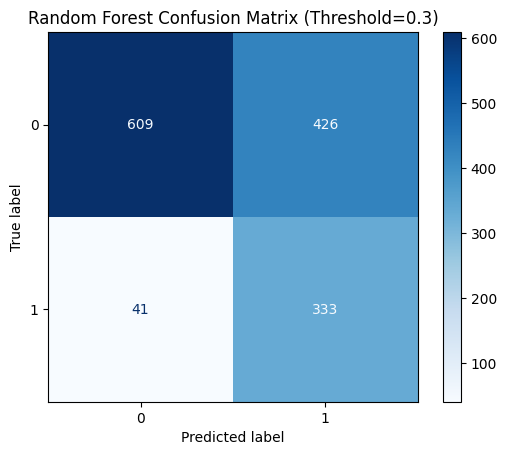

In [91]:
cm_rf_final = confusion_matrix(y_test, y_pred_rf_final)
disp_rf_final = ConfusionMatrixDisplay(confusion_matrix=cm_rf_final)

disp_rf_final.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix (Threshold=0.3)")
plt.show()

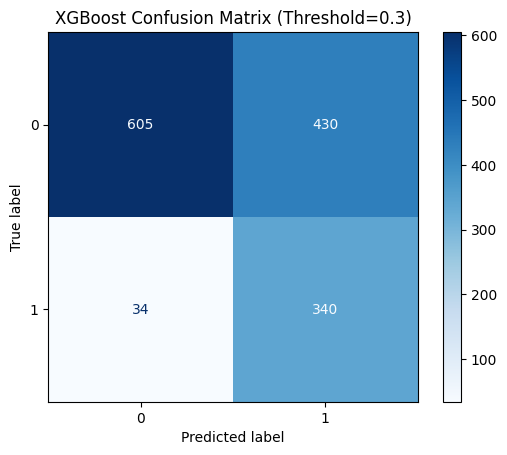

In [92]:
cm_xgb_final = confusion_matrix(y_test, y_pred_xgb_final)
disp_xgb_final = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_final)

disp_xgb_final.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix (Threshold=0.3)")
plt.show()

XGBoost is better because it reduces false negatives and captures more churn customers with only a minimal increase in false positives.

Section 8. Model Interpretation

1. Feature Importance

(a) XGBoost Feature Importance

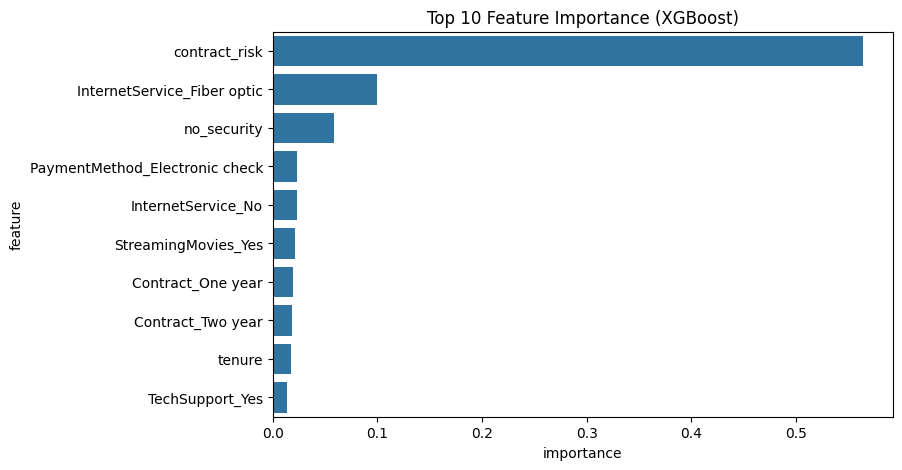

In [93]:
xgb_importance = xgb_model.feature_importances_ #XGBoost 모델에서 feature importance 추출

xgb_feat = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_importance
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="importance", y="feature", data=xgb_feat)
plt.title("Top 10 Feature Importance (XGBoost)")
plt.show()

(b) SHAP

In [94]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

In [95]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

C:\Users\Windows11\AppData\Local\Temp\ipykernel_22536\1673247600.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_df)


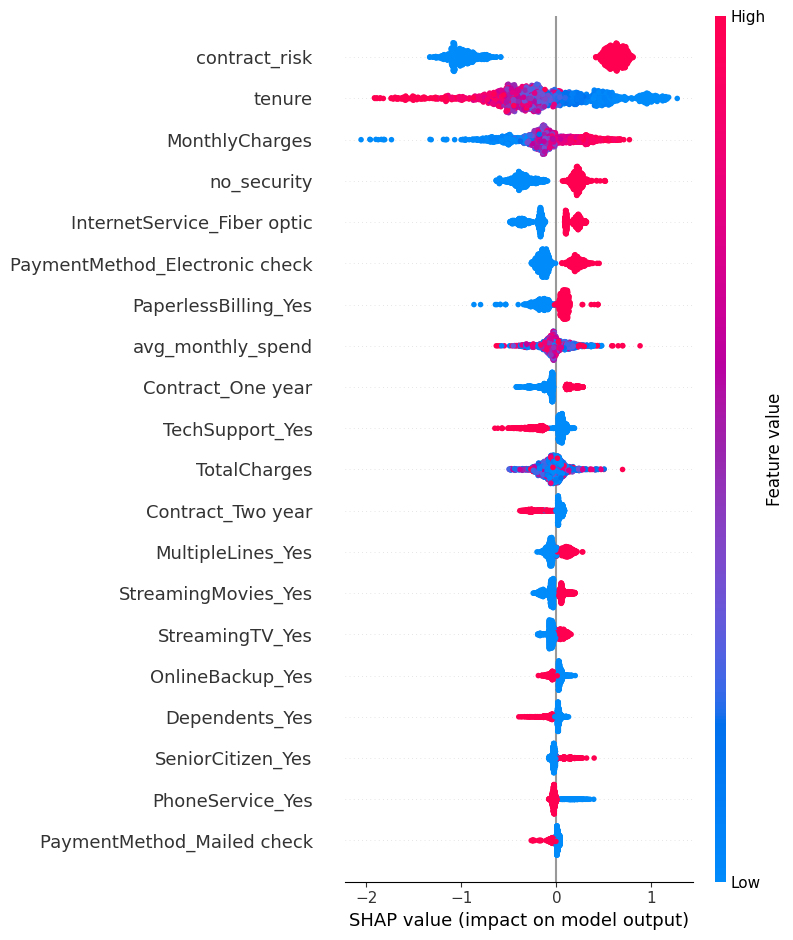

C:\Users\Windows11\AppData\Local\Temp\ipykernel_22536\1673247600.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_df, plot_type="bar")


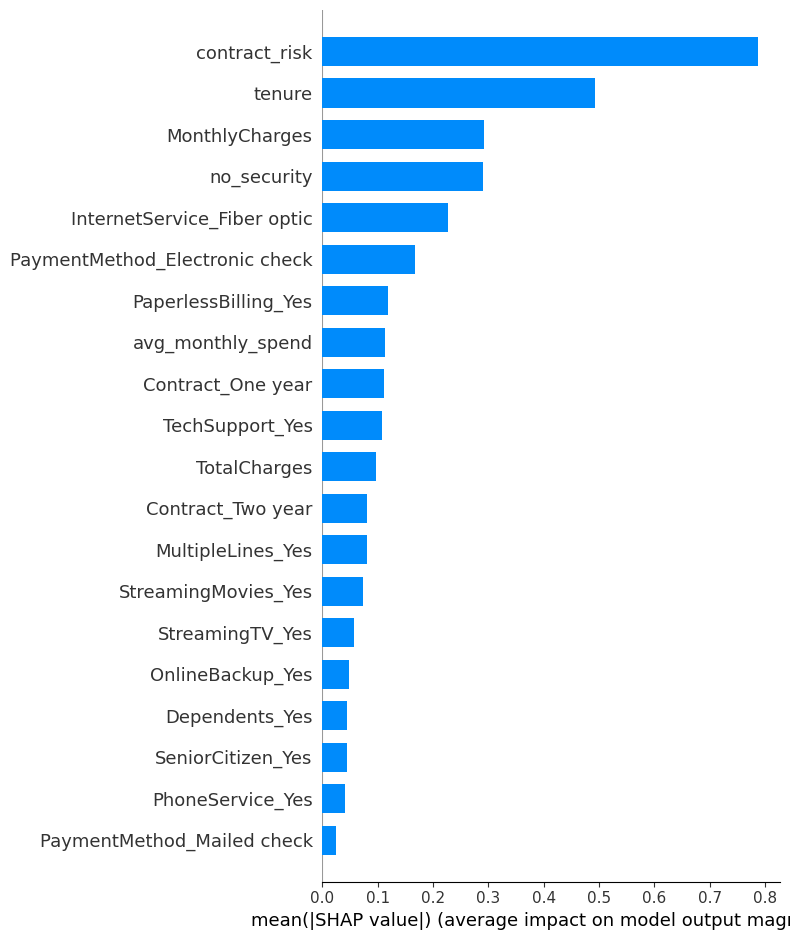

In [96]:
shap.summary_plot(shap_values, X_test_df)

shap.summary_plot(shap_values, X_test_df, plot_type="bar")

In [97]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_df.iloc[0]
)

Section 8. Final Model Selection Statement

## Final Model Selection

Among all evaluated models, XGBoost achieved the best performance in terms of recall, which is the most critical metric for customer churn prediction.

Threshold optimization demonstrated that lowering the classification threshold significantly improved recall, enabling the model to capture more potential churn cases.

Although hyperparameter tuning was conducted, the tuned XGBoost model did not outperform the original model in recall. Therefore, the original XGBoost model was selected as the final model.

Final Model:
Original XGBoost with threshold = 0.3

DEMO (streamlit)

In [100]:
import joblib

joblib.dump(xgb_model, "final_xgb.pkl")

['final_xgb.pkl']

In [101]:
artifacts = {
    "model": xgb_model,   
    "scaler": scaler,
    "threshold": 0.3,     
    "feature_columns": X.columns.tolist()
}

joblib.dump(artifacts, "churn_artifacts.pkl")

['churn_artifacts.pkl']

In [102]:
artifacts = joblib.load("churn_artifacts.pkl")

model = artifacts["model"]
scaler = artifacts["scaler"]
threshold = artifacts["threshold"]
feature_columns = artifacts["feature_columns"]